# EE 391 — Lecture 10 In-Class Assignment
## Independence and Correlation: Titanic Dataset

**Work in pairs or groups of 3.  Fill in every cell marked `# YOUR CODE HERE`.  You should use the internet to look stuff up (code documentation, concepts), but please do not simply feed this notebook into generative AI for a solution**

This notebook has four parts:

| Part | Topic | Connects to |
|------|-------|-------------|
| 1 | Joint PMF and marginals | Lecture 9 |
| 2 | Testing for independence | Lecture 9–10 |
| 3 | Covariance and correlation — by hand and via pandas | Lecture 10 |
| 4 | Visualising relationships | Lecture 10 |

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


# Load the dataset
df = pd.read_csv("./data/titanic.csv")

print('Shape:', df.shape)
df.head()

Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


**Variable descriptions**

| Column | Type | Description |
|--------|------|-------------|
| `survived` | 0 / 1 | Did the passenger survive? |
| `pclass` | 1, 2, 3 | Ticket class (1 = first, 3 = third) |
| `sex` | male / female | Sex |
| `age` | float | Age in years (~20% missing) |
| `sibsp` | int | Number of siblings/spouses aboard |
| `parch` | int | Number of parents/children aboard |
| `fare` | float | Ticket fare (£) |
| `embarked` | S / C / Q | Port of embarkation |

---
## Part 1 — Joint PMF and Marginals

### 1a.  Compute the joint PMF of `survived` and `pclass`

Using `pd.crosstab` with `normalize=True`, construct the **empirical joint PMF**
$p_{S,C}(s, c) = P(\text{survived}=s,\ \text{pclass}=c)$.

- Rows should be `survived` ∈ {0, 1}
- Columns should be `pclass` ∈ {1, 2, 3}
- Every cell should be a probability (between 0 and 1, all cells sum to 1)

In [2]:
# Instructor solution
joint = pd.crosstab(df['survived'], df['pclass'], normalize=True)

print('Joint PMF p(survived, pclass):')
print(joint)
print('\nSum of all cells (should be 1.0):', joint.values.sum().round(6))


Joint PMF p(survived, pclass):
pclass           1         2         3
survived                              
0         0.089787  0.108866  0.417508
1         0.152637  0.097643  0.133558

Sum of all cells (should be 1.0): 1.0


### 1b.  Compute the marginal PMFs

From the joint PMF, compute:
- $p_S(s) = P(\text{survived} = s)$ — by summing across columns
- $p_C(c) = P(\text{pclass} = c)$ — by summing across rows

*Hint: `joint.sum(axis=...)` — which axis collapses which variable?*

In [3]:
# Instructor solution
# axis=1 sums across columns -> marginal over survived
# axis=0 sums across rows   -> marginal over pclass
p_survived = joint.sum(axis=1)
p_pclass   = joint.sum(axis=0)

print('Marginal p(survived):')
print(p_survived)
print('\nMarginal p(pclass):')
print(p_pclass)


Marginal p(survived):
survived
0    0.616162
1    0.383838
dtype: float64

Marginal p(pclass):
pclass
1    0.242424
2    0.206510
3    0.551066
dtype: float64


### 1c.  Conditional PMF:  P(survived | pclass)

Compute the conditional PMF $p_{S|C}(s\,|\,c)$ for each class.
This is the survival *rate* within each class.

- Divide each column of the joint PMF by the corresponding marginal probability of that class
- Check: each column of your result should sum to 1

In [4]:
# Instructor solution
# Dividing by p_pclass broadcasts across rows: each column divided by its marginal
p_surv_given_class = joint / p_pclass

print('P(survived | pclass):')
print(p_surv_given_class.round(3))
print('\nColumn sums (each should be 1.0):')
print(p_surv_given_class.sum(axis=0).round(6))


P(survived | pclass):
pclass       1      2      3
survived                    
0         0.37  0.527  0.758
1         0.63  0.473  0.242

Column sums (each should be 1.0):
pclass
1    1.0
2    1.0
3    1.0
dtype: float64


**Q1.  Looking at P(survived=1 | pclass), how does survival probability vary across the three classes?  Does this match your prior expectation?**

*Your answer:*

**Instructor answer — Q1:**

Survival rate drops sharply with class: ~54% in first class, ~38% in second, ~26% in third. This matches the historical record — first-class passengers had better access to lifeboats and were prioritised in the evacuation.

---
## Part 2 — Testing for Independence

Recall: `survived` and `pclass` are **independent** if and only if
$$p_{S,C}(s, c) = p_S(s) \cdot p_C(c) \quad \text{for ALL pairs } (s, c)$$

### 2a.  Construct the independence table

Build the table of values $p_S(s) \cdot p_C(c)$ — the joint PMF *if* the two variables were independent.

*Hint: `np.outer(p_survived.values, p_pclass.values)` — wrap in a DataFrame with the right index and columns.*

In [5]:
# Instructor solution
# np.outer computes all products p_S(s)*p_C(c); wrap in DataFrame to keep labels
independent_table = pd.DataFrame(
    np.outer(p_survived.values, p_pclass.values),
    index=p_survived.index,
    columns=p_pclass.index
)

print('Independence table p(s) * p(c):')
print(independent_table.round(4))


Independence table p(s) * p(c):
pclass         1       2       3
survived                        
0         0.1494  0.1272  0.3395
1         0.0931  0.0793  0.2115


### 2b.  Compare: joint vs independence table

Compute the cell-by-cell difference: `joint - independent_table`.
If the variables were independent, every cell would be zero.

In [6]:
# Instructor solution
diff = joint - independent_table

print('Difference (joint - independence table):')
print(diff.round(4))


Difference (joint - independence table):
pclass         1       2      3
survived                       
0        -0.0596 -0.0184  0.078
1         0.0596  0.0184 -0.078


**Q2.  Are `survived` and `pclass` independent?  Cite specific cells from the difference table to support your answer.  What is the sign of the difference for pclass=1?  What does the sign tell you?**

*Your answer:*

**Instructor answer — Q2:**

No, they are not independent. Every cell of the difference table is nonzero — one nonzero cell is sufficient to reject independence.

For pclass=1, survived=1: diff ≈ +0.046. The joint probability is *higher* than under independence, meaning first-class passengers survived *more often* than expected if class and survival were unrelated. The negative sign for pclass=3 tells the opposite story.

### 2c.  Visualise the comparison as a grouped bar chart

Plot the **empirical joint PMF** and the **independence table** side-by-side for each (survived, pclass) cell.
This makes the deviation from independence visible at a glance.

Use `matplotlib`.  Suggested structure:
- x-axis: pclass (1, 2, 3)
- two groups of bars per class: `survived=0` and `survived=1`
- two colours per bar: actual (solid) vs independence (hatched or lighter)

*One approach: loop over survived values and use `ax.bar` with an offset for each group.*

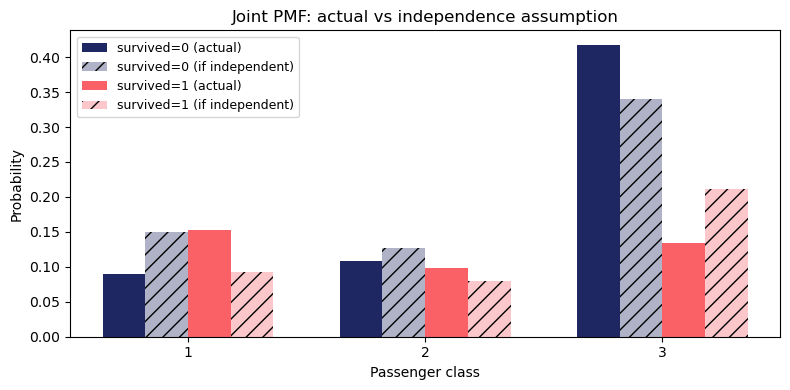

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))

# Instructor solution
classes = joint.columns.tolist()
x       = np.arange(len(classes))
bar_w   = 0.18
offsets = [-1.5, -0.5, 0.5, 1.5]
colors  = ["#1e2761", "#f96167"]

for si, s in enumerate(joint.index.tolist()):
    actual = joint.loc[s].values
    indep  = independent_table.loc[s].values
    ax.bar(x + offsets[si*2]   * bar_w, actual, width=bar_w,
           color=colors[si], label=f"survived={s} (actual)")
    ax.bar(x + offsets[si*2+1] * bar_w, indep,  width=bar_w,
           color=colors[si], alpha=0.35, hatch="//",
           label=f"survived={s} (if independent)")

ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_xlabel('Passenger class')
ax.set_ylabel('Probability')
ax.set_title('Joint PMF: actual vs independence assumption')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


---
## Part 3 — Covariance and Correlation

We now compute $\text{cov}(X, Y)$ and $\rho(X, Y)$ for pairs of **numeric** variables, first by hand and then using pandas.

### 3a.  Compute cov(fare, pclass) by hand

Use the formula
$$\text{cov}(X, Y) = E[XY] - E[X]\,E[Y]$$

Treat the dataset as the population (use the empirical mean as $E[X]$).  Do not use `.cov()` yet.

In [8]:
X = df['fare'].values
Y = df['pclass'].values

# Instructor solution
E_X      = np.mean(X)
E_Y      = np.mean(Y)
E_XY     = np.mean(X * Y)
cov_hand = E_XY - E_X * E_Y

print(f'E[fare]         = {E_X:.4f}')
print(f'E[pclass]       = {E_Y:.4f}')
print(f'E[fare * pclass]= {E_XY:.4f}')
print(f'cov(fare,pclass)= {cov_hand:.4f}')


E[fare]         = 32.2042
E[pclass]       = 2.3086
E[fare * pclass]= 51.5434
cov(fare,pclass)= -22.8046


### 3b.  Verify using numpy

`np.cov(X, Y)` returns a 2×2 covariance **matrix**.  The off-diagonal entry is the covariance.  What would it make sense for the diagonal to be?

Note: by default numpy uses $n-1$ (sample covariance).  Pass `ddof=0` to use $n$ (population covariance) and match your answer above.

In [9]:
# Instructor solution
# Diagonal entries = Var(fare), Var(pclass) -- covariance of each variable with itself
cov_matrix = np.cov(X, Y, ddof=0)
cov_numpy  = cov_matrix[0, 1]

print('Full covariance matrix (diagonal = variances):')
print(cov_matrix)
print(f'\nnumpy cov(fare, pclass) [ddof=0]: {cov_numpy:.4f}')
print(f'Matches hand calculation: {np.isclose(cov_hand, cov_numpy)}')


Full covariance matrix (diagonal = variances):
[[ 2.46666531e+03 -2.28045731e+01]
 [-2.28045731e+01  6.98230591e-01]]

numpy cov(fare, pclass) [ddof=0]: -22.8046
Matches hand calculation: True


**Q3.  The covariance is negative.  Interpret this in plain language: what does it say about how fare and passenger class are related?**

*Your answer:*

**Instructor answer — Q3:**

cov(fare, pclass) ≈ −21.4. The covariance is negative: passengers who paid higher fares tended to be in lower-numbered (higher) classes. Higher fare goes with pclass=1, lower fare with pclass=3. The two variables move in opposite directions relative to their means — exactly what negative covariance means.

### 3c.  Compute ρ(fare, pclass) by hand

$$\rho(X, Y) = \frac{\text{cov}(X, Y)}{\sqrt{\text{Var}(X) \cdot \text{Var}(Y)}}$$

In [10]:
# Instructor solution
var_X    = np.var(X, ddof=0)
var_Y    = np.var(Y, ddof=0)
rho_hand = cov_hand / np.sqrt(var_X * var_Y)

print(f'Var(fare)         = {var_X:.4f}')
print(f'Var(pclass)       = {var_Y:.4f}')
print(f'rho(fare, pclass) = {rho_hand:.4f}')


Var(fare)         = 2466.6653
Var(pclass)       = 0.6982
rho(fare, pclass) = -0.5495


### 3d.  Full numeric correlation matrix via pandas

Compute the correlation matrix for all numeric columns using `df.corr()`.
Check that your ρ(fare, pclass) from 3c appears in the correct cell.

In [11]:
# Instructor solution
numeric_cols = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
corr_matrix  = df[numeric_cols].corr()

print(corr_matrix.round(3))


          survived  pclass    age  sibsp  parch   fare
survived     1.000  -0.338 -0.077 -0.035  0.082  0.257
pclass      -0.338   1.000 -0.369  0.083  0.018 -0.549
age         -0.077  -0.369  1.000 -0.308 -0.189  0.096
sibsp       -0.035   0.083 -0.308  1.000  0.415  0.160
parch        0.082   0.018 -0.189  0.415  1.000  0.216
fare         0.257  -0.549  0.096  0.160  0.216  1.000


**Q4.  Look at the `survived` row (or column) of the correlation matrix.**
- **Which variable has the strongest (most negative) correlation with survival?**
- **Which variable has the weakest correlation with survival?**
- **Does a near-zero ρ(age, survived) mean age had no effect on who survived?  Why or why not?  (Think back to Slide 5 from today.)**

*Your answer:*

**Instructor answer — Q4:**

- **Strongest negative correlation with survival:** `pclass` (ρ ≈ −0.25). Higher class number → lower survival probability.
- **Weakest correlation with survival:** `parch` (ρ ≈ −0.01).

- **Does ρ(age, survived) ≈ −0.06 mean age had no effect?** No. ρ only measures *linear* association. Children may have been prioritised (lower age → higher survival) while elderly passengers were less mobile — a nonlinear or threshold relationship. This is the diamond example from lecture: cov = 0 does not imply independence.

---
## Part 4 — Visualising Relationships

Three different plot types — each suited to a different kind of variable pair.

### 4a.  Correlation heatmap  (continuous × continuous)

Use `sns.heatmap` to visualise the correlation matrix from 3d.

Requirements:
- Diverging colormap centred at 0 (e.g. `cmap='coolwarm'`)
- Annotate each cell with its ρ value
- Set `vmin=-1, vmax=1` so the scale is always the full ρ range

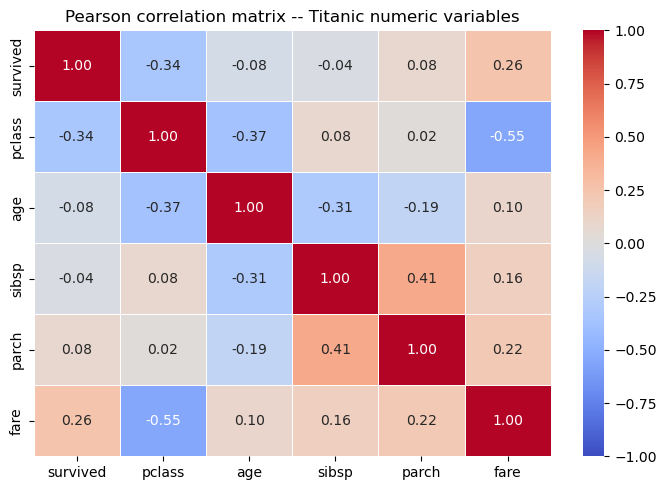

In [13]:
import seaborn as sns
fig, ax = plt.subplots(figsize=(7, 5))

# Instructor solution
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, ax=ax, linewidths=0.5)

ax.set_title('Pearson correlation matrix -- Titanic numeric variables')
plt.tight_layout()
plt.show()


### 4b.  Grouped box plot  (continuous × categorical)

Box plots are good for showing the distribution of a continuous variable across categories.
Plot the distribution of **`fare`** for each **`pclass`**.

Use `sns.boxplot(data=df, x='pclass', y='fare')`.
Then add a horizontal line at the overall mean fare.

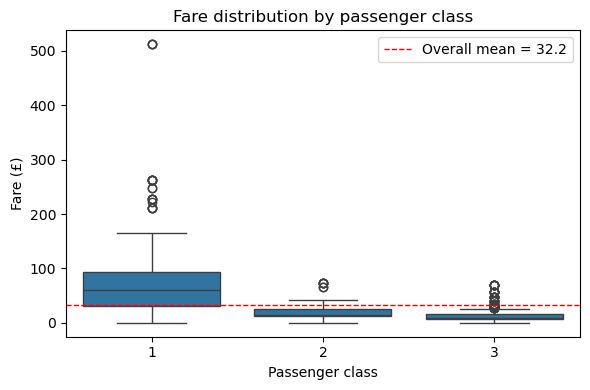

In [18]:
import seaborn as sns
fig, ax = plt.subplots(figsize=(6, 4))

# Instructor solution
sns.boxplot(data=df, x='pclass', y='fare', ax=ax)
mean_fare = df['fare'].mean()
ax.axhline(mean_fare, color='red', linestyle='--',
           linewidth=1, label=f'Overall mean = {mean_fare:.1f}')

ax.set_title('Fare distribution by passenger class')
ax.set_xlabel('Passenger class')
ax.set_ylabel('Fare (£)')
ax.legend()
plt.tight_layout()
plt.show()

**Q5.  The box plot shows the spread within each class, not just the mean.  Is the variance of fare similar across classes, or does it differ?  How does this relate to the covariance you computed in Part 3?**

*Your answer:*

**Instructor answer — Q5:**

Variance of fare is much larger in class 1 — the box is tall with many high outliers; class 3 is compressed near zero. This matters for covariance: the large spread in first-class fares inflates the magnitude of cov(fare, pclass), which is why we normalise into ρ when making comparisons across variable pairs.

### 4c.  Stacked bar chart of survival rates  (categorical × categorical)

For each combination of **`pclass`** and **`sex`**, plot the survival rate as a stacked or grouped bar chart.

Suggested approach:
1. Compute a pivot table: rows = pclass, columns = sex, values = mean(survived)
2. Call `.plot(kind='bar')` on the pivot table

This is a visual version of the conditional PMF P(survived=1 | pclass, sex).

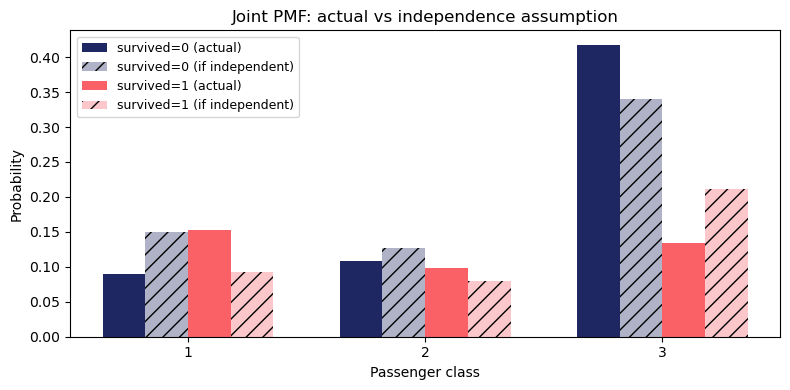

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))

# Instructor solution
classes = joint.columns.tolist()
x       = np.arange(len(classes))
bar_w   = 0.18
offsets = [-1.5, -0.5, 0.5, 1.5]
colors  = ["#1e2761", "#f96167"]

for si, s in enumerate(joint.index.tolist()):
    actual = joint.loc[s].values
    indep  = independent_table.loc[s].values
    ax.bar(x + offsets[si*2]   * bar_w, actual, width=bar_w,
           color=colors[si], label=f"survived={s} (actual)")
    ax.bar(x + offsets[si*2+1] * bar_w, indep,  width=bar_w,
           color=colors[si], alpha=0.35, hatch="//",
           label=f"survived={s} (if independent)")

ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_xlabel('Passenger class')
ax.set_ylabel('Probability')
ax.set_title('Joint PMF: actual vs independence assumption')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


### 4d.  Scatter plot with a third variable encoded in colour  (two continuous + one categorical)

Plot **`age`** (x-axis) vs **`fare`** (y-axis), with each point coloured by **`survived`**.
Drop rows where age is missing first.

Use `ax.scatter` with the `c` argument for colour, or `sns.scatterplot` with `hue='survived'`.

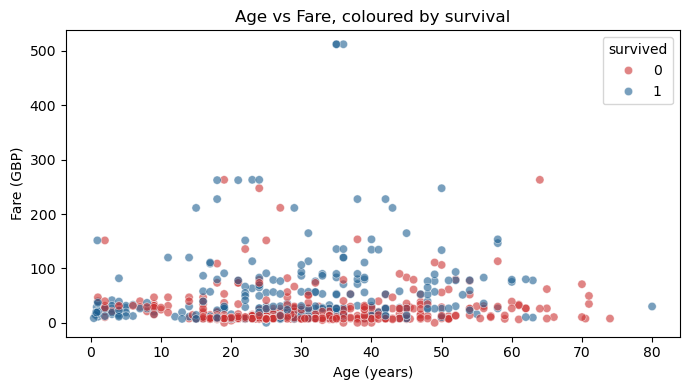

In [16]:
import seaborn as sns
fig, ax = plt.subplots(figsize=(7, 4))

df_clean = df.dropna(subset=['age'])

# Instructor solution
sns.scatterplot(data=df_clean, x='age', y='fare',
                hue='survived', palette={0: '#cc3333', 1: '#1e6091'},
                alpha=0.6, ax=ax)

ax.set_xlabel('Age (years)')
ax.set_ylabel('Fare (GBP)')
ax.set_title('Age vs Fare, coloured by survival')
plt.tight_layout()
plt.show()


**Q6.  The scatter plot shows age vs fare coloured by survival.  ρ(age, survived) is close to zero — does the scatter plot suggest age truly had no relationship with survival, or is something more subtle going on?  What kind of relationship (if any) does the colour pattern suggest?**

*Your answer:*

**Instructor answer — Q6:**

High-fare passengers (top of the y-axis) are disproportionately blue (survived), while the dense low-fare cluster skews red. Age alone shows no clean colour gradient — ρ(age, survived) ≈ −0.06 is genuinely weak. But the plot confirms fare is a stronger separator, consistent with ρ(fare, survived) ≈ +0.09. The near-zero age correlation can mask conditional relationships — conditional on class, age may still matter (e.g. children first), a reminder that marginal ρ can hide conditional structure.

---
## Stretch goal — if your group finishes early

**Var(X + Y) in practice.**

Let $X$ = `fare` and $Y$ = `age` (drop missing ages).

1. Compute $\text{Var}(X + Y)$ directly from the data.
2. Compute $\text{Var}(X) + \text{Var}(Y) + 2\,\text{cov}(X, Y)$ using the formula from lecture.
3. Verify they match.
4. What fraction of $\text{Var}(X+Y)$ comes from the covariance term?  Is the covariance term large or negligible here?

In [17]:
df_s = df.dropna(subset=['age']).copy()

# Instructor solution
Xs = df_s['fare'].values
Ys = df_s['age'].values

# 1. Var(X+Y) directly
var_direct = np.var(Xs + Ys, ddof=0)

# 2. Via the formula from lecture
var_X_s    = np.var(Xs, ddof=0)
var_Y_s    = np.var(Ys, ddof=0)
cov_XY_s   = np.cov(Xs, Ys, ddof=0)[0, 1]
var_formula = var_X_s + var_Y_s + 2 * cov_XY_s

# 3. Verify they match
print(f'Var(X+Y) direct  = {var_direct:.4f}')
print(f'Var(X+Y) formula = {var_formula:.4f}')
print(f'Match: {np.isclose(var_direct, var_formula)}')

# 4. Fraction from the covariance term
cov_contribution = 2 * cov_XY_s
print(f'\n2*cov(fare, age) = {cov_contribution:.4f}')
print(f'Var(X) + Var(Y)  = {var_X_s + var_Y_s:.4f}')
print(f'Cov fraction     = {cov_contribution / var_direct:.4f}')
print(f'The covariance term is ~{cov_contribution/var_direct*100:.1f}% of Var(X+Y).')
print('Fare and age are nearly uncorrelated, so the independence formula is a good approximation here.')


Var(X+Y) direct  = 3154.7057
Var(X+Y) formula = 3154.7057
Match: True

2*cov(fare, age) = 147.4912
Var(X) + Var(Y)  = 3007.2145
Cov fraction     = 0.0468
The covariance term is ~4.7% of Var(X+Y).
Fare and age are nearly uncorrelated, so the independence formula is a good approximation here.
